# Notebook 2 — Preprocessing

This notebook transforms the raw FER2013 arrays produced by the data loader into
training-ready tensors. We produce **two versions** of the processed data:

- **Grayscale 48 × 48 × 1** — native FER2013 resolution, used by the custom CNN.
- **RGB 96 × 96 × 3** — upscaled and channel-duplicated, used by MobileNetV2.

Both versions are persisted to `data/processed/` so that the training notebook
(Notebook 3) can reload them in seconds without repeating this pipeline.

We also compute class weights and configure the data-augmentation pipeline.
Note that the class weights end up unused in training because of a TF 2.10
bug with one-hot labels (see `dev_log.md`); they are saved here for reference
and as a documentation artefact of the imbalance, but the imbalance itself
is handled by augmentation + light dropout in Notebook 3.

## Section 1 — Setup and data loading

We fix all random seeds before any array manipulation so that the train/val split
is reproducible across runs. The raw images are loaded as uint8 grayscale arrays
of shape `(n, 48, 48)` via `load_fer2013`, which also handles the stratified
validation split. Printing shapes here confirms that we start from the expected
data before any transformation.

In [1]:
import random
import sys
from pathlib import Path

import numpy as np
import tensorflow as tf

# Make src importable from the notebook directory
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src import config
from src.data.loader import load_fer2013

SEED = config.RANDOM_SEED
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

X_train, y_train, X_val, y_val, X_test, y_test = load_fer2013(config.RAW_DIR)

print(f"X_train: {X_train.shape}  dtype={X_train.dtype}")
print(f"X_val:   {X_val.shape}  dtype={X_val.dtype}")
print(f"X_test:  {X_test.shape}  dtype={X_test.dtype}")
print(f"y_train: {y_train.shape}  labels {y_train.min()}–{y_train.max()}")

X_train: (24402, 48, 48)  dtype=uint8
X_val:   (4307, 48, 48)  dtype=uint8
X_test:  (7178, 48, 48)  dtype=uint8
y_train: (24402,)  labels 0–6


## Section 2 — Normalization

Pixel values are divided by 255 to map from uint8 [0, 255] to float32 [0, 1].
Keeping raw byte values would cause very large activations in the first layer,
slowing convergence and making gradient-based optimisers less stable.
MobileNetV2 additionally expects inputs in this range because its batch-norm
statistics were calibrated during ImageNet pretraining on [0, 1] tensors.
Decision: simple division by 255 rather than per-channel standardisation
(mean/std), because FER2013 is grayscale and the channel-specific statistics
would add complexity without meaningful benefit for this dataset.

In [2]:
X_train_f = X_train.astype(np.float32) / 255.0
X_val_f   = X_val.astype(np.float32)   / 255.0
X_test_f  = X_test.astype(np.float32)  / 255.0

print(f"Pixel range after normalisation: [{X_train_f.min():.3f}, {X_train_f.max():.3f}]")
print(f"dtype: {X_train_f.dtype}")

Pixel range after normalisation: [0.000, 1.000]
dtype: float32


## Section 3 — Reshape for the custom CNN

Keras `Conv2D` layers expect a 4-D input `(batch, height, width, channels)`.
The loader returns 3-D arrays `(n, 48, 48)`, so we add a trailing axis of size 1
to produce `(n, 48, 48, 1)`. This represents a single grayscale channel and is
the correct input shape for our custom CNN.

In [3]:
X_train_gray = X_train_f[..., np.newaxis]   # (n, 48, 48, 1)
X_val_gray   = X_val_f[..., np.newaxis]
X_test_gray  = X_test_f[..., np.newaxis]

print(f"Custom CNN input — train: {X_train_gray.shape}, val: {X_val_gray.shape}, test: {X_test_gray.shape}")

Custom CNN input — train: (24402, 48, 48, 1), val: (4307, 48, 48, 1), test: (7178, 48, 48, 1)


## Section 4 — Prepare MobileNetV2 inputs

MobileNetV2 was pretrained on ImageNet, which contains natural colour photographs.
To reuse its convolutional filters we must supply 3-channel tensors: a single
grayscale channel would produce incompatible activation maps for the pretrained
weights. We duplicate the single channel three times — a standard, computationally
cheap workaround for grayscale datasets.

We also resize from 48 × 48 to **96 × 96**. MobileNetV2's native ImageNet input
is 224 × 224 and Keras documents 96 × 96 as the official minimum useful size.
A previous version of this notebook used 64 × 64 to keep inference latency low,
but that left the backbone with only a 2 × 2 spatial feature map after its ~32×
internal downsampling — almost no spatial information for the head to work with,
which cost ~15 pts of validation accuracy. 96 × 96 yields a 3 × 3 feature map
and recovers most of that gap while keeping inference fast enough for the
webcam demo.</cell id="57ab9245">

In [4]:
from src.data.loader import resize_batch, to_rgb

TARGET = config.IMG_SIZE_MOBILENET  # (96, 96)

X_train_rgb = to_rgb(resize_batch(X_train_f, TARGET))   # (n, 96, 96, 3)
X_val_rgb   = to_rgb(resize_batch(X_val_f,   TARGET))
X_test_rgb  = to_rgb(resize_batch(X_test_f,  TARGET))

print(f"MobileNetV2 input — train: {X_train_rgb.shape}, val: {X_val_rgb.shape}, test: {X_test_rgb.shape}")
print(f"Pixel range: [{X_train_rgb.min():.3f}, {X_train_rgb.max():.3f}]  dtype: {X_train_rgb.dtype}")

MobileNetV2 input — train: (24402, 96, 96, 3), val: (4307, 96, 96, 3), test: (7178, 96, 96, 3)
Pixel range: [0.000, 1.000]  dtype: float32


## Section 5 — One-hot encoding of labels

Our loss function will be `categorical_crossentropy`, which expects one-hot
vectors rather than integer class indices. `tf.keras.utils.to_categorical`
converts each integer label in 0–6 to a vector of length 7.
The discarded alternative is `sparse_categorical_crossentropy` with integer
labels, which would skip this step. We prefer one-hot encoding because it
makes the label representation explicit in saved arrays and simplifies
metric calculations in the evaluation notebook.

In [5]:
NUM_CLASSES = len(config.EMOTION_LABELS)  # 7

y_train_oh = tf.keras.utils.to_categorical(y_train, NUM_CLASSES)
y_val_oh   = tf.keras.utils.to_categorical(y_val,   NUM_CLASSES)
y_test_oh  = tf.keras.utils.to_categorical(y_test,  NUM_CLASSES)

print(f"y_train_oh shape: {y_train_oh.shape}  example: {y_train_oh[0]}")

y_train_oh shape: (24402, 7)  example: [0. 0. 1. 0. 0. 0. 0.]


## Section 6 — Class weights computation

FER2013 is heavily imbalanced: *Happy* (6133 train samples) has roughly
**16 × more samples than *Disgust*** (371). Without correction the model
tends to learn to predict the majority class and ignore rare emotions —
a critical failure for the sales-receptivity use case where *Disgust*
and *Fear* are among the most actionable signals.

`compute_class_weight("balanced")` computes a weight per class that is
inversely proportional to class frequency, so that — if the weights are
applied in the loss — the optimiser pays proportionally more attention
to rare examples. The output below shows that *Disgust* would receive a
weight of ~9.4 while *Happy* would receive ~0.57.

**Caveat: these weights are saved for reference but are not passed to
`model.fit()` in Notebook 3.** TF 2.10's weighted-loss path on one-hot
labels has a known bug that collapses training to uniform output (see
`dev_log.md`, Phase 5 problems 1 and 2). The same bug applies whether
the weights come from `class_weight` or `sample_weight`. The imbalance
is instead absorbed by augmentation + light dropout in Notebook 3 — by
construction the model learns to do the easy majority class first
(*Happy* plateau in epochs 1-3) and gradually picks up the rare classes
as augmentation surfaces more varied examples of them.

In [6]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.arange(NUM_CLASSES)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weights = {int(i): float(w) for i, w in zip(classes, weights)}

print("Class weights:")
for idx, label in enumerate(config.EMOTION_LABELS):
    print(f"  {idx}  {label:<10}  {class_weights[idx]:.4f}")

Class weights:
  0  angry       1.0265
  1  disgust     9.3962
  2  fear        1.0011
  3  happy       0.5684
  4  sad         0.8492
  5  surprise    1.2935
  6  neutral     0.8261


## Section 7 — Augmentation pipeline configuration

We apply online augmentation during training to improve generalisation to real
webcam conditions. The parameters are chosen to reflect realistic variation:
±15° rotation covers natural head tilts without distorting facial geometry;
10% shifts and zoom simulate slight framing differences between clips;
brightness variation in [0.8, 1.2] mirrors the wide range of office and
conference-room lighting. Vertical flip is intentionally excluded because
upside-down faces are not a valid real-world input and would degrade learning.

In [7]:
from src.data.augmentation import build_augmentation_pipeline

datagen = build_augmentation_pipeline(for_minority_classes=False)
print("Augmentation pipeline configured:")
print(f"  rotation_range:     {datagen.rotation_range}°")
print(f"  width_shift_range:  {datagen.width_shift_range}")
print(f"  height_shift_range: {datagen.height_shift_range}")
print(f"  zoom_range:         {datagen.zoom_range}")
print(f"  horizontal_flip:    {datagen.horizontal_flip}")
print(f"  brightness_range:   {datagen.brightness_range}")

Augmentation pipeline configured:
  rotation_range:     15°
  width_shift_range:  0.1
  height_shift_range: 0.1
  zoom_range:         0.1
  horizontal_flip:    True
  brightness_range:   (0.8, 1.2)


## Section 8 — Augmentation visualization

To build intuition for what the model sees during training, we take one random
training image and apply the augmentation pipeline 8 times. The resulting 3 × 3
grid (original + 8 variants) shows the range of rotations, brightness shifts,
and spatial distortions the network must learn to be invariant to — which
directly corresponds to the natural variation expected from a live webcam stream
during a sales call.

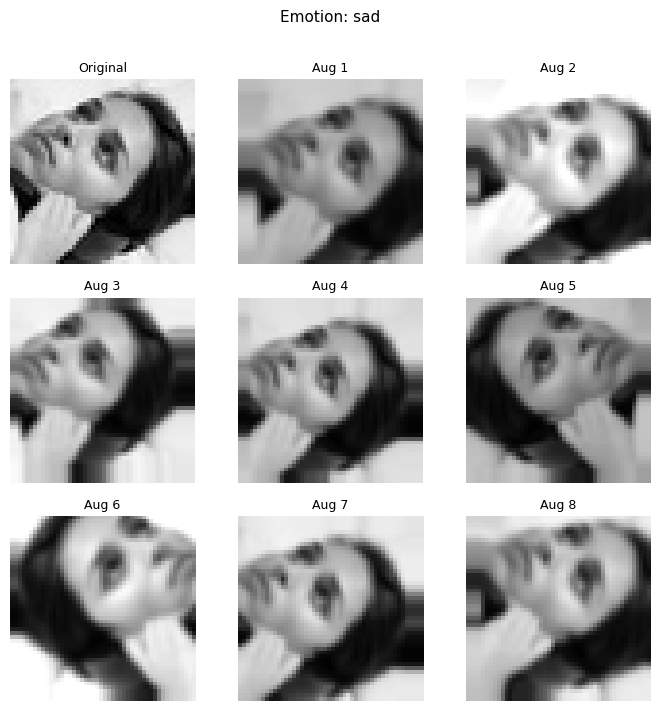

In [8]:
import matplotlib.pyplot as plt

rng = np.random.default_rng(SEED)
idx = rng.integers(len(X_train_gray))
sample = X_train_gray[idx]                        # (48, 48, 1)
label_name = config.EMOTION_LABELS[y_train[idx]]

np.random.seed(SEED)
augmented = [datagen.random_transform(sample) for _ in range(8)]

fig, axes = plt.subplots(3, 3, figsize=(7, 7))
all_images = [sample] + augmented
titles = ["Original"] + [f"Aug {i+1}" for i in range(8)]

for ax, img, title in zip(axes.flat, all_images, titles):
    ax.imshow(img.squeeze(), cmap="gray", vmin=0, vmax=1)
    ax.set_title(title, fontsize=9)
    ax.axis("off")

fig.suptitle(f"Emotion: {label_name}", fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

## Section 9 — Save processed datasets

Persisting the processed tensors means Notebook 3 can load them directly in
a few seconds instead of re-running the full preprocessing pipeline (which
involves reading thousands of JPEGs, resizing, and channel operations).
We save three artefacts: a grayscale `.npz` for the custom CNN, an RGB `.npz`
for MobileNetV2, and a JSON file for the class weights dictionary. The `.npz`
format is space-efficient and loads with a single `np.load` call.

In [9]:
import json

config.PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# Grayscale dataset (custom CNN)
gray_path = config.PROCESSED_DIR / "fer2013_gray.npz"
np.savez_compressed(
    gray_path,
    X_train=X_train_gray, y_train=y_train_oh,
    X_val=X_val_gray,     y_val=y_val_oh,
    X_test=X_test_gray,   y_test=y_test_oh,
)
print(f"Saved: {gray_path}  ({gray_path.stat().st_size / 1e6:.1f} MB)")

# RGB 96×96 dataset (MobileNetV2)
rgb_path = config.PROCESSED_DIR / "fer2013_rgb96.npz"
np.savez_compressed(
    rgb_path,
    X_train=X_train_rgb, y_train=y_train_oh,
    X_val=X_val_rgb,     y_val=y_val_oh,
    X_test=X_test_rgb,   y_test=y_test_oh,
)
print(f"Saved: {rgb_path}  ({rgb_path.stat().st_size / 1e6:.1f} MB)")

# Class weights
weights_path = config.PROCESSED_DIR / "class_weights.json"
with open(weights_path, "w") as f:
    json.dump(class_weights, f, indent=2)
print(f"Saved: {weights_path}")

Saved: C:\Users\jpulg\Documents\Todo\Proyectos\sales-receptivity-cnn\data\processed\fer2013_gray.npz  (106.8 MB)
Saved: C:\Users\jpulg\Documents\Todo\Proyectos\sales-receptivity-cnn\data\processed\fer2013_rgb96.npz  (991.1 MB)
Saved: C:\Users\jpulg\Documents\Todo\Proyectos\sales-receptivity-cnn\data\processed\class_weights.json


### Validation: reload and verify

Before proceeding we confirm that both `.npz` files load correctly and that
the class-weights JSON has exactly 7 entries. This catches any serialisation
issue immediately rather than letting it surface during training.

In [10]:
gray_check = np.load(gray_path)
rgb_check  = np.load(rgb_path)
with open(weights_path) as f:
    cw_check = json.load(f)

print("Gray splits:",  {k: gray_check[k].shape for k in gray_check})
print("RGB splits:",   {k: rgb_check[k].shape  for k in rgb_check})
print(f"Class weights: {len(cw_check)} entries — {cw_check}")

assert len(cw_check) == NUM_CLASSES, "Expected 7 class-weight entries"
print("\nAll validation checks passed.")

Gray splits: {'X_train': (24402, 48, 48, 1), 'y_train': (24402, 7), 'X_val': (4307, 48, 48, 1), 'y_val': (4307, 7), 'X_test': (7178, 48, 48, 1), 'y_test': (7178, 7)}
RGB splits: {'X_train': (24402, 96, 96, 3), 'y_train': (24402, 7), 'X_val': (4307, 96, 96, 3), 'y_val': (4307, 7), 'X_test': (7178, 96, 96, 3), 'y_test': (7178, 7)}
Class weights: 7 entries — {'0': 1.0265017667844523, '1': 9.39622641509434, '2': 1.0011487650775417, '3': 0.5684004565465515, '4': 0.8492082825822168, '5': 1.2935064935064935, '6': 0.8260663507109005}

All validation checks passed.


## Section 10 — Summary and link to the next notebook

This notebook completed the full preprocessing pipeline for FER2013:

| Step | Output |
|------|--------|
| Normalisation | float32 pixels in [0, 1] |
| Custom CNN arrays | `(n, 48, 48, 1)` → `data/processed/fer2013_gray.npz` (~107 MB) |
| MobileNetV2 arrays | `(n, 96, 96, 3)` → `data/processed/fer2013_rgb96.npz` (~991 MB) |
| One-hot labels | 7-class vectors for all three splits |
| Class weights | `data/processed/class_weights.json` — saved for reference; not used by Notebook 3 because of the TF 2.10 weighting bug |
| Augmentation | Pipeline configured (rotation ±15°, shifts ±10 %, zoom ±10 %, horizontal flip, brightness ×[0.8, 1.2]) and visualised on one sample |

**Next: Notebook 3 — Training** (`03_model_training.ipynb`).  
It loads the two `.npz` files produced here, instantiates both model
architectures from `src/models/`, and runs the training loop with the
default callbacks (`EarlyStopping` patience=12, `ReduceLROnPlateau`
patience=5, `ModelCheckpoint`). Neither `class_weight` nor `sample_weight`
is passed to `model.fit()`.